# 📊 Data preprocessing - Full
**Full preprocessing of clinical retinal fundus images.**

The purpose of this notebook is to apply the full preprocessing pipeline to retinal fundus images from the clinical dataset.

Unlike the previous public dataset version, images are not loaded from class folders. Instead, this notebook reads a clinical match table where each row links:

- image path
- filename
- patient ID
- eye laterality
- image metadata
- refractive data
- spherical equivalent target
- binary myopia label

The output will be a new preprocessed image folder and an updated match table pointing to the preprocessed images.

## 📚 1. Importing Libraries
Loading the necessary libraries for data analysis and images preprocessing.

In [1]:
# Some basic libraries
import os
import glob
import math
import shutil

from pathlib import Path
from typing import Tuple, Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For images preprocessing
import cv2
from PIL import Image

# For deep learning
import tensorflow as tf
from tensorflow import keras

In [2]:
# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


At this stage, the notebook is running on CPU only, which is fine for prototyping and testing the preprocessing pipeline. Once the pipeline is finalized, the notebook can be moved to a GPU-enabled environment (e.g., Kaggle or Google Colab) to accelerate model training.

Note: CUDA acceleration was attempted but turned out to be only available on NVIDIA GPUs. Since this Jupyter Lab environment does not provide a compatible NVIDIA GPU, all computations currently fall back to the CPU.


## 🛠️  2. Helpers preparation

To keep the codebase clean and efficient, several helper functions were implemented.  
These functions encapsulate small, reusable tasks that will be required multiple times throughout the preprocessing pipeline.

Using helper functions ensures:
- Reusability: the same logic can be applied in different parts of the code without duplication.  
- Readability: the main pipeline remains concise, while the detailed operations are abstracted away.  
- Maintainability: if a method needs adjustment (e.g., changing the CLAHE parameters), only the helper function needs to be updated.

First, we declare a parameter container for further use. This way we provide the same parameters on all models

In [3]:
# Project root detection - mejor orden en jupyter
PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "0B_TFGBiomed":
    PROJECT_ROOT = PROJECT_ROOT.parent

IMAGES_DIR = PROJECT_ROOT / "Images"
TABLES_DIR = PROJECT_ROOT / "Tables"
SPLITS_DIR = PROJECT_ROOT / "Splits"
MODELS_DIR = PROJECT_ROOT / "Models"

for folder in [IMAGES_DIR, TABLES_DIR, SPLITS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
    
class CFG:
    INPUT_TABLE = TABLES_DIR / "MatchTables" / "Tabla_MatchImagenesConDatosClinicos.xlsx" # Input clinical match table
    INPUT_IMAGE_DIR = IMAGES_DIR / "00_OG_GaldosPictures" #Carpeta donde están las imágenes ORIGINALES 
    OUTPUT_DIR = IMAGES_DIR / "01_FullPreprocessing_GaldosPictures" # Output folder for fully preprocessed images - new folder will be created
    OUTPUT_TABLE = TABLES_DIR / "MatchTables" / "Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx" # Output updated match table
    
    IMAGE_SIZE = 224                  # final square size (e.g., 224 tamaño og, 256 tamaño habitual ImageNet, 299)
    APPLY_CLAHE = True                # Contrast Limited Adaptive Histogram Equalization
    CLAHE_MODE = "luminance"          # choosing CLAHE channel from "luminance" | "green" | "blue" | "none"
    NORMALIZATION = "0-1"             # "0-1" | "zscore" | "imagenet"
    
    OUTPUT_EXT = ".jpg" # Output format
    JPG_QUALITY = 95                  # 
    VERBOSE = True                    # gives messages while preprocessing for visual progress

# Reproducibility: setting set split, weights and training on same random parameter making it easier to compare modelss
np.random.seed(42)

In [4]:
# Create required folders
CFG.INPUT_TABLE.parent.mkdir(parents=True, exist_ok=True)
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CFG.OUTPUT_TABLE.parent.mkdir(parents=True, exist_ok=True)

assert CFG.INPUT_TABLE.exists(), f"Missing input table: {CFG.INPUT_TABLE}"
assert CFG.INPUT_IMAGE_DIR.exists(), f"Missing input image folder: {CFG.INPUT_IMAGE_DIR}"

Helpers (funciones auxiliares empleadas en repetidas ocasiones):

#### 2.1. Loading the clinical match table

The match table is loaded from Excel. Only rows with valid image paths and valid clinical targets are kept.

For this project, the relevant target columns are:

- `target_SE`: spherical equivalent used for regression.
- `class_label`: binary myopia label used for classification.

In [5]:
def rebuild_input_paths_from_filename(df, input_dir):
    input_dir = Path(input_dir)

    filename_to_path = {
        p.name: str(p.resolve())
        for p in list(input_dir.rglob("*.jpg")) + list(input_dir.rglob("*.jpeg")) + list(input_dir.rglob("*.png"))
    }

    df = df.copy()
    df["image_path"] = df["filename"].map(filename_to_path)

    missing = df["image_path"].isna().sum()

    print("Images found:", df["image_path"].notna().sum())
    print("Images missing:", missing)

    if missing > 0:
        print("Examples missing:")
        print(df[df["image_path"].isna()]["filename"].head(10).tolist())

    return df

In [6]:
df = pd.read_excel(CFG.INPUT_TABLE)
df = rebuild_input_paths_from_filename(df, CFG.INPUT_IMAGE_DIR)

Images found: 2346
Images missing: 0


In [7]:
# Keep only rows with valid image paths and targets
df = df[df["image_path"].notna()].copy()
df = df[df["filename"].notna()].copy()
df = df[df["target_SE"].notna()].copy()
df = df[df["class_label"].notna()].copy()

df["image_path"] = df["image_path"].astype(str)
df["filename"] = df["filename"].astype(str)
df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
df["target_SE"] = pd.to_numeric(df["target_SE"], errors="coerce")
df["class_label"] = pd.to_numeric(df["class_label"], errors="coerce").astype("Int64")

df = df.dropna(subset=["image_path", "filename", "patient_id", "target_SE", "class_label"]).copy()

print("Total valid rows:", len(df))
print("\nClassification label balance:")
print(df["class_label"].value_counts())

print("\nTarget SE summary:")
print(df["target_SE"].describe())

df.head()

Total valid rows: 2126

Classification label balance:
class_label
0    1645
1     481
Name: count, dtype: Int64

Target SE summary:
count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,OI_ESF,OI_CIL,OI_EJE,EquivalenteEsférico_Derecho,EquivalenteEsférico_Izquierdo,¿Revisar?,Ultimavisita_dt,match_type,target_SE,class_label
0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6.0,...,0.00,0.00,0.0,0.00,0.000,SI,2024-09-17,id+date,0.000,0
1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6.0,...,0.00,0.00,0.0,0.00,0.000,SI,2024-09-17,id+date,0.000,0
2,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51.0,...,-0.25,-0.75,180.0,-2.25,-0.625,NO,2023-12-11,id+date,-2.250,1
3,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51.0,...,-0.25,-0.75,180.0,-2.25,-0.625,NO,2023-12-11,id+date,-0.625,1
4,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26.0,...,-0.25,0.00,0.0,0.00,-0.250,NO,2023-04-12,id+date,0.000,0


#### 🖼️  2.2. Image I/O
Reading images in BGR format (`read_image_bgr`) and converting them to RGB (`bgr_to_rgb`).

In [8]:
def read_image_bgr(path: str) -> np.ndarray:
    #Reads image with cv2 (Pyhton module for OpenCV, faster than keras o tensorflow) in BGR space (RBG in different order for cv2); returns np.uint8 array
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Failed to read image: {path}")
    return img

def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    #Necessary conversion bc OpenCV works on BGR but deep learning libraries expect RGB
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def rgb_to_bgr(img_rgb: np.ndarray) -> np.ndarray: # Converts RGB image back to BGR for OpenCV saving.
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

#### 📂  2.3. File management
Creating directories when needed (`ensure_dir`).

In [9]:
def ensure_dir(path: str):
    #Creates directory if does not yet exist
    os.makedirs(path, exist_ok=True)

#### 📐  2.4. Geometry operations
Padding an image to a square shape without distortion (`center_pad_to_square`).

In [10]:
def center_pad_to_square(img: np.ndarray, value: int = 0) -> np.ndarray:
    #Calculates how much space the image needs to become square. Pads images with square black shape around the center (without distorting the eye)
    h, w = img.shape[:2]
    side = max(h, w)
    top = (side - h) // 2
    bottom = side - h - top
    left = (side - w) // 2
    right = side - w - left
    return cv2.copyMakeBorder(img, top, bottom, left, right, borderType=cv2.BORDER_CONSTANT, value=[value, value, value])

#### 🎯  2.5. Circular ROI
Circular ROI (Region Of Interest) detection helpers: tries Hough first, if it fails it falls back to largest contour, if both fail it keeps the original image (but still pads & resizes).

In [11]:
def detect_fundus_circle(img_bgr: np.ndarray) -> Optional[Tuple[int, int, int]]:
    # Tries to detect the circular fundus (gives back center x, y and radius r of circle)
    # It first tries Hough and if not, Fallback
    
    # Grayscale to simplify calculations (no color means less noise)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 7) # even less noise with median filter

    # A) Uses HoughCircles on the blurred grayscale
    # Tries finding circles on image based on margins and gradients
    circles = cv2.HoughCircles(
        gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=min(gray.shape)//2, #dp resolution, minDist between circles so they are not too close
        param1=60, param2=30, minRadius=min(gray.shape)//6, maxRadius=min(gray.shape)//1 #radius sizes for expected circles
    )
    if circles is not None and len(circles) > 0:
        circles = np.uint16(np.around(circles[0]))
        # Pick the largest circle (safer in clutter)
        cx, cy, r = max(circles, key=lambda c: c[2])
        return int(cx), int(cy), int(r) # Returns (cx, cy, r) in pixel coords, or None if not found.

    # B) Fallback: if Hough does not find circles then threshold + largest contour -> minEnclosingCircle
    # Adaptive threshold to separate bright disc from background
    thr = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY, 51, 2)
    # Keep largest bright component on image (will be the whole fundus)
    contours, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        (x, y), r = cv2.minEnclosingCircle(cnt)
        return int(x), int(y), int(r)

    return None

def circular_crop(img_bgr: np.ndarray, circle: Tuple[int,int,int]) -> np.ndarray:
    # Crops the circular ROI and creates black background outside
    h, w = img_bgr.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8) #black mask for backgorund
    cx, cy, r = circle
    cv2.circle(mask, (cx, cy), r, 255, -1) # 0-255 grayscale for mask, -1 is circle thickness (cv2 gets whole circle this way)
    fg = cv2.bitwise_and(img_bgr, img_bgr, mask=mask) # Apply mask
    # Bounding square around the circle and deleting rest:
    x1, y1 = max(cx - r, 0), max(cy - r, 0)
    x2, y2 = min(cx + r, w), min(cy + r, h)
    cropped = fg[y1:y2, x1:x2]
    return cropped

#### ✨  2.6. Enhancement
Applying CLAHE for local contrast improvement (`apply_clahe`).

CLAHE (Contrast Limited Adaptive Histogram Equalization) is an image processing technique that:  
- Enhances the local contrast of an image.  
- Prevents overly bright regions from becoming saturated (contrast limited).  
- Is especially useful in medical imaging (e.g., retinal fundus photographs), as it highlights details such as blood vessels and the optic disc.  

Note:
By default, CLAHE is applied on the luminance channel (LAB-L), which usually improves retinal contrast without introducing color artifacts.  
Since this dataset contains blue fundus images, we can also experiment with `CLAHE_MODE="blue"` and compare results.


In [12]:
def apply_clahe(img_bgr: np.ndarray, mode: str = "luminance") -> np.ndarray:
    if mode == "none": #no changes to og image
        return img_bgr

    if mode == "luminance": #convert to LAB (Lightness/Green-Red/Blue-Yellow), apply CLAHE on L (Luminance) channel
        #LAB separates luminance from color so we can change light only afterwards (CLAHE) and not colors - very useful in medicine
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)) #contrast limit and grid splitting for CLAHE on each block
        l2 = clahe.apply(l)
        lab2 = cv2.merge([l2, a, b])
        return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

    b, g, r = cv2.split(img_bgr)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    #chooses which color channel applies CLAHE to 
    if mode == "green": #apply CLAHE on green channel only (good for blood vessels)
        g = clahe.apply(g)
    elif mode == "blue": #apply CLAHE on blue channel only
        b = clahe.apply(b)
    else:
        return img_bgr
    return cv2.merge([b, g, r])

#### ⚖️  2.7. Normalization
Scaling pixel values into a consistent range (e.g., [0–1], z-score, or ImageNet mean/std) to stabilize training and ensure compatibility with deep learning models.

In [13]:
# Mean and standard deviation values of each RGB channel, calculated on ImageNet dataset (we use the same for standardization)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def normalize(img_rgb: np.ndarray, mode: str = "0-1") -> np.ndarray:
    # Normalize image to float32 (decimals necessary on deep learning since we'll normalize values 0-1)
    x = img_rgb.astype(np.float32)

    if mode == "0-1": #scale to [0,1] (for models from scratch)
        x /= 255.0
        return x

    if mode == "zscore": #per-image (x - mean) / std (can help if illuminaion varies a lot accross images)
        x /= 255.0
        m = x.mean(axis=(0,1), keepdims=True)
        s = x.std(axis=(0,1), keepdims=True) + 1e-6
        return (x - m) / s

    if mode == "imagenet": #(x/255 - mean) / std (for transfer learning pretrained backbones)
        x /= 255.0
        return (x - IMAGENET_MEAN) / IMAGENET_STD

    # default just in case
    x /= 255.0
    return x #returns float32 RGB image


def to_uint8_for_saving(img_rgb_float: np.ndarray, normalization: str = "0-1") -> np.ndarray: # Converts normalized float image back to uint8 for saving
    x = img_rgb_float.copy()
    
    if normalization == "0-1":
        x = x * 255.0
    elif normalization == "zscore":
        x = (x - x.min()) / (x.max() - x.min() + 1e-6)
        x = x * 255.0
    elif normalization == "imagenet":
        x = (x * IMAGENET_STD + IMAGENET_MEAN) * 255.0

    x = np.clip(x, 0, 255).astype(np.uint8)
    return x

#### 🧩  2.8. Preprocessing pipeline for single image

The function `preprocess_image()` applies the full preprocessing pipeline to a single fundus image using the parameters defined in `CFG`.  

Steps:
1. **Circle detection & cropping**: localizes the retinal fundus and removes irrelevant background.  
2. **Square padding & resizing**: pads the image to preserve aspect ratio, then resizes to `CFG.IMAGE_SIZE`.  
3. **Contrast enhancement (optional)**: applies CLAHE depending on `CFG.APPLY_CLAHE` and `CFG.CLAHE_MODE`.  
4. **Color conversion & normalization**: converts BGR→RGB and normalizes pixel values according to `CFG.NORMALIZATION`.  

Output: a `float32` RGB image of shape `(IMAGE_SIZE, IMAGE_SIZE, 3)`, normalized and ready for model input.


In [14]:
def preprocess_image(path: str, cfg: CFG = CFG) -> np.ndarray: #preprocessing pipeline of 1 image with class CFG params
    img_bgr = read_image_bgr(path)

    # 1) Detect circle & crop
    circle = detect_fundus_circle(img_bgr)
    if circle is not None:
        img_bgr = circular_crop(img_bgr, circle)
    # if fundus not detected: leave as is (some datasets will already be centered)

    # 2) Pad to square (keeps circle centered), then resize
    img_bgr = center_pad_to_square(img_bgr, value=0)
    img_bgr = cv2.resize(img_bgr, (cfg.IMAGE_SIZE, cfg.IMAGE_SIZE), interpolation=cv2.INTER_AREA)

    # 3) CLAHE (optional)
    if cfg.APPLY_CLAHE and cfg.CLAHE_MODE != "none":
        img_bgr = apply_clahe(img_bgr, mode=cfg.CLAHE_MODE)

    # 4) Convert to RGB and normalize
    img_rgb = bgr_to_rgb(img_bgr)
    img_rgb = normalize(img_rgb, mode=cfg.NORMALIZATION)

    return img_rgb #returns float32 RGB image of shape (IMAGE_SIZE, IMAGE_SIZE, 3) normalized per cfg.NORMALIZATION

#### 👀  2.9. Preview utilities

Allows for gridview

In [15]:
def show_grid(images: List[np.ndarray], titles: Optional[List[str]] = None, cols: int = 4, suptitle: str = ""): #to see pics in grid
    rows = math.ceil(len(images) / cols)
    plt.figure(figsize=(3*cols, 3*rows))
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i+1)
        # assume RGB float or uint8
        if img.dtype != np.uint8 and img.max() <= 1.0:
            plt.imshow(img)
        else:
            plt.imshow(img.astype(np.uint8))
        plt.axis('off')
        if titles:
            plt.title(titles[i], fontsize=9)
    if suptitle:
        plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


def preview_samples(df: pd.DataFrame, cfg: CFG = CFG, k: int = 8): # Shows preview of k preprocessed images from clinical match table
    sample_df = df.sample(min(k, len(df)), random_state=42)
    imgs = []
    titles = []

    for _, row in sample_df.iterrows():
        try:
            img = preprocess_image(row["image_path"], cfg)
            imgs.append(img)
            titles.append(row["filename"])
        except Exception as e:
            print("Preview error:", row["image_path"], e)

    show_grid(imgs, titles=titles, cols=4, suptitle="Full preprocessing preview")

#### 📦  2.10. Batch export:
Saving all our preprocessed pics correctly, row by row.

For each image:

- the original image is read from `image_path`,
- the full preprocessing pipeline is applied,
- the resulting image is saved into `CFG.OUTPUT_DIR`,
- the table is updated so `image_path` points to the new preprocessed image.

All clinical columns are preserved.

In [17]:
def export_preprocessed_dataset(df: pd.DataFrame, cfg: CFG = CFG, limit: Optional[int] = None) -> pd.DataFrame:
    # Applies the complete preprocessing pipeline to all images listed in the clinical match table.
    # Returns an updated dataframe where image_path points to the preprocessed image

    # Remove any previous preprocessing output folder to avoid mixing old and new results.
    # This guarantees that the exported dataset only contains images generated in the current run.
    if cfg.OUTPUT_DIR.exists():
        shutil.rmtree(cfg.OUTPUT_DIR)

    # Create a fresh output directory where all preprocessed images will be stored
    ensure_dir(cfg.OUTPUT_DIR)

    # Work on a copy of the dataframe to avoid modifying the original table in memory
    work_df = df.copy()

    # Optional debugging mode: if limit is specified, only the first N images are processed.
    if limit is not None:
        work_df = work_df.head(limit).copy()
        
    new_paths = [] #list for new paths of exported
    failed_rows = [] #rows failed to preprocess

    for idx, row in work_df.iterrows():
        src_path = row["image_path"] #OG path
        filename = Path(row["filename"]).stem + cfg.OUTPUT_EXT #Generate output filename
        dst_path = cfg.OUTPUT_DIR / filename #final destination for preproc pic

        try: #apply full preproc
            img = preprocess_image(src_path, cfg) 

            img_uint8 = to_uint8_for_saving( #normalized float image to uint8
                img,
                normalization=cfg.NORMALIZATION
            )

            cv2.imwrite( #save processed image to disk
                str(dst_path),
                rgb_to_bgr(img_uint8), #OpenCV expects BGR images, so RGB is converted back beforehand
                [cv2.IMWRITE_JPEG_QUALITY, cfg.JPG_QUALITY]
            )

            new_paths.append(str(dst_path.resolve())) #store absolute path of newly generated image

        except Exception as e:
            print(f"Failed: {src_path} -> {e}") # If preprocessing fails, report the error but continue processing rest of images
            new_paths.append(pd.NA) #store missing value for failed images
            failed_rows.append(idx) #save row index for later reporting

    work_df["original_image_path"] = work_df["image_path"] #preserve og path
    work_df["image_path"] = new_paths #replace with preproc image path
    work_df["preprocessing"] = "full" #store prepoc pic metadata
    work_df["image_size"] = cfg.IMAGE_SIZE
    work_df["clahe_applied"] = cfg.APPLY_CLAHE
    work_df["clahe_mode"] = cfg.CLAHE_MODE

    work_df = work_df[work_df["image_path"].notna()].copy() #remove rows that could not be preprocessed

    print("Export finished.")
    print("Successful images:", len(work_df))
    print("Failed images:", len(failed_rows))
    print("Output folder:", cfg.OUTPUT_DIR)

    return work_df # Return updated clinical table linked to the newly preprocessed images

## 🗂️ 3. Preprocessing the Dataset
Finally getting to the preprocessing. The data is loaded from a folder in the workspace.

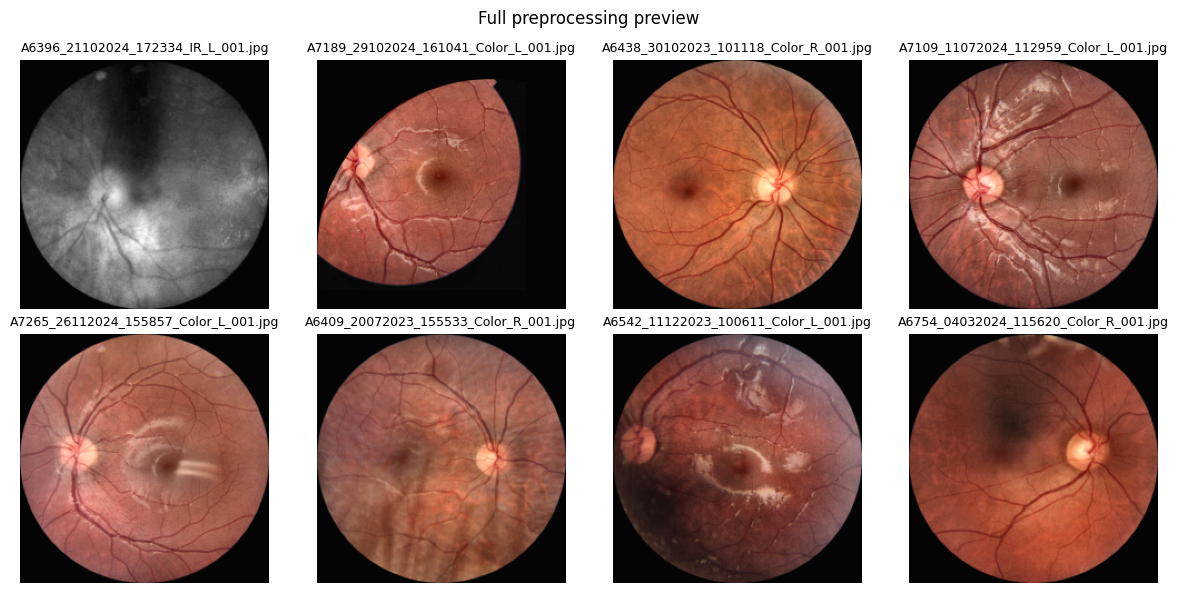

In [18]:
# Quick visual preview on 8 pics
preview_samples(df, CFG, k=8)

In [19]:
# For testing, use a small limit first, e.g. limit=50
# Once verified, set limit=None to preprocess the full dataset

df_full_preproc = export_preprocessed_dataset(df, CFG, limit=None)
df_full_preproc.to_excel(CFG.OUTPUT_TABLE, index=False)

print("Updated match table saved at:", CFG.OUTPUT_TABLE)
df_full_preproc.head()

Export finished.
Successful images: 2126
Failed images: 0
Output folder: C:\Users\paula\0B_TFGBiomed\Images\01_FullPreprocessing_GaldosPictures
Updated match table saved at: C:\Users\paula\0B_TFGBiomed\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,¿Revisar?,Ultimavisita_dt,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6.0,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
1,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6.0,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
2,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51.0,...,NO,2023-12-11,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
3,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51.0,...,NO,2023-12-11,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
4,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26.0,...,NO,2023-04-12,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance


Making sure all pictures are preprocessed:

In [20]:
def count_images_in_dir(path: Path): # Counts image files inside a directory
    image_extensions = {".jpg", ".jpeg", ".png"}

    files = [
        p for p in path.rglob("*")
        if p.is_file() and p.suffix.lower() in image_extensions
    ]

    return len(files)

n_exported = count_images_in_dir(CFG.OUTPUT_DIR)
print("Images in output directory:", n_exported)
print("Rows in updated table:", len(df_full_preproc))

missing_paths = df_full_preproc["image_path"].apply(lambda p: not Path(p).exists()).sum()
print("Missing paths in updated table:", missing_paths)

if len(df_full_preproc) == 0:
    print("Warning: no images were exported. Please review input paths.")
elif n_exported == len(df_full_preproc) and missing_paths == 0:
    print("Ready! All exported images are correctly linked in the updated table.")
else:
    print("Warning: mismatch detected. Please review exported files and table paths.")

Images in output directory: 2126
Rows in updated table: 2126
Missing paths in updated table: 0
Ready! All exported images are correctly linked in the updated table.


Ready! All images have been properly preprocessed :)